# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Detecting Support and Resistance Levels

In the previous units, we learned to identify the support and resistance levels on a price chart.

In this notebook, we will see how we can programmatically identify the support and resistance levels for the price series of an asset.

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Resample the Data](#resample)
4. [Identify the Support and Resistance Levels](#identify_levels)
5. [Plot the Nearest Support and Resistance Levels](#plot)
6. [Functions for Determining the Nearest Support and Resistance Levels](#functions)
7. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import numpy as np
import pandas as pd

# For visualisation
import mplfinance as mpf

# For datetime manipulation
from datetime import timedelta

# To ignore warnings
import warnings
warnings.simplefilter('ignore')

# To calculate swing highs and lows
from scipy.signal import argrelextrema
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import get_min_max

<a id='data'></a>
## Read the Data

Import the file `c_minute_2015_2021.csv` using the `read_csv` method of `pandas`. This file has the minute wise OHLCV values for the Citigroup stock. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv('../data_modules/c_minute_2015_2021.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.head()

,Close,High,Low,Open,Volume
2015-01-02 09:30:00+00:00,54.61,54.62,54.35,54.36,819855.0
2015-01-02 09:31:00+00:00,54.58,54.64,54.52,54.59,23892.0
2015-01-02 09:32:00+00:00,54.66,54.69,54.55,54.56,51169.0
2015-01-02 09:33:00+00:00,54.55,54.67,54.54,54.66,46634.0
2015-01-02 09:34:00+00:00,54.47,54.56,54.46,54.54,43558.0


<a id='resample'></a>
## Resample the Data

We will resample the minute data to daily data. To learn more about the resample function, you can visit the official documentation page <a href='https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html' target="_blank">here</a>.

In [3]:
# Aggregate function
ohlcv_dict = {'Open': 'first',
              'High': 'max',
              'Low': 'min',
              'Close': 'last',
              'Volume': 'sum'
             }

# Resample the data
data_daily = data.resample('1d', label='left', closed='right').agg(ohlcv_dict).dropna()

# Adjust the index values
data_daily.index += timedelta(hours=15, minutes=59)

# Display the resampled data
data_daily.head()

,Open,High,Low,Close,Volume
2015-01-02 15:59:00+00:00,54.36,54.69,53.79,54.25,9960628.0
2015-01-05 15:59:00+00:00,53.91,53.96,52.33,52.52,17154836.0
2015-01-06 15:59:00+00:00,52.67,52.76,50.53,50.68,30198704.0
2015-01-07 15:59:00+00:00,51.50,51.56,50.62,51.17,24675786.0
2015-01-08 15:59:00+00:00,51.83,52.08,51.50,51.92,15708929.0


<a id='identify_levels'></a>
## Identify the Support and Resistance Levels

In the following cell, we will identify the support and resistance levels for the initial `90` days. 

1. We will create a dataframe `data_90` consisting of the OHLCV values of the first `90` days. We have taken the timeperiod of `90` days as we are interested in finding the support and resistance levels for the past 2-3 months' data. You can modify this value as per your strategy logic. 

2. We will use the `get_min_max` function from the `price_action_util_quantra` library to get the support and resistance levels. The function takes `data` and `argrel_window` as arguments and returns support and resistance levels.

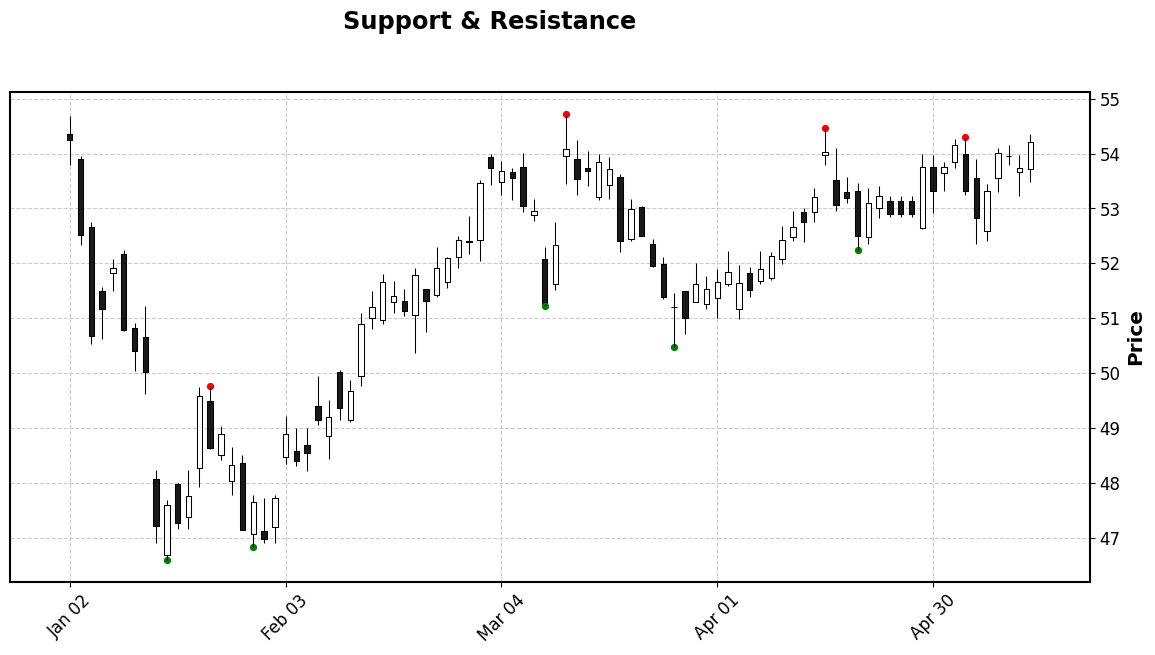

In [4]:
# Create a dataframe with data of initial 90 days
data_90 = data_daily.iloc[:90]

# Set the argel_window as 5
argrel_window = 5

# Get support and resistance levels
data_90['Support'], data_90['Resistance'] = get_min_max(data_90, argrel_window)

# Additional plots for marking the support and resistance levels
apd = [mpf.make_addplot(data_90.Support, type='scatter', color="green"),
       mpf.make_addplot(data_90.Resistance, type='scatter', color="red")]

# Plot the OHLC data along with the support and resistance levels
mpf.plot(data_90, type='candle', style='classic',
         addplot=apd, title='Support & Resistance', figsize=(15, 7))

As you may have observed in the above figure, the support and resistance levels have been identified and highlighted with the help of green and red markers, respectively.

<a id='plot'></a>
## Nearest Support and Resistance Levels

In the above code cell, we saw that we can identify multiple support and resistance levels. Why do we need to find the nearest support/resistance levels? It is because if the price has bounced back from a support/resistance level at least once, then there is a higher chance that the level might again act as a support/resistance level. Also, the more recent the level is, the higher the chance that the level might get tested again sometime soon. Now, how do we select the most important support/resistance level? There are two conditions for that:

1. A level can be considered as a support level if the `ltp` is greater than the support level and vice versa in case of the resistance level.

In [5]:
# Get the last traded price
ltp = data_90.Close.iloc[-1]

# Check whether the price is greater than LTP for the support levels
data_90['Support'] = np.where(data_90['Support'] < ltp, data_90['Support'], np.nan)

# Check whether the price is less than LTP for the resistance levels
data_90['Resistance'] = np.where(data_90['Resistance'] > ltp, data_90['Resistance'], np.nan)

2. We will select the most recent levels as there is a higher chance that the level might get tested again sometime soon.

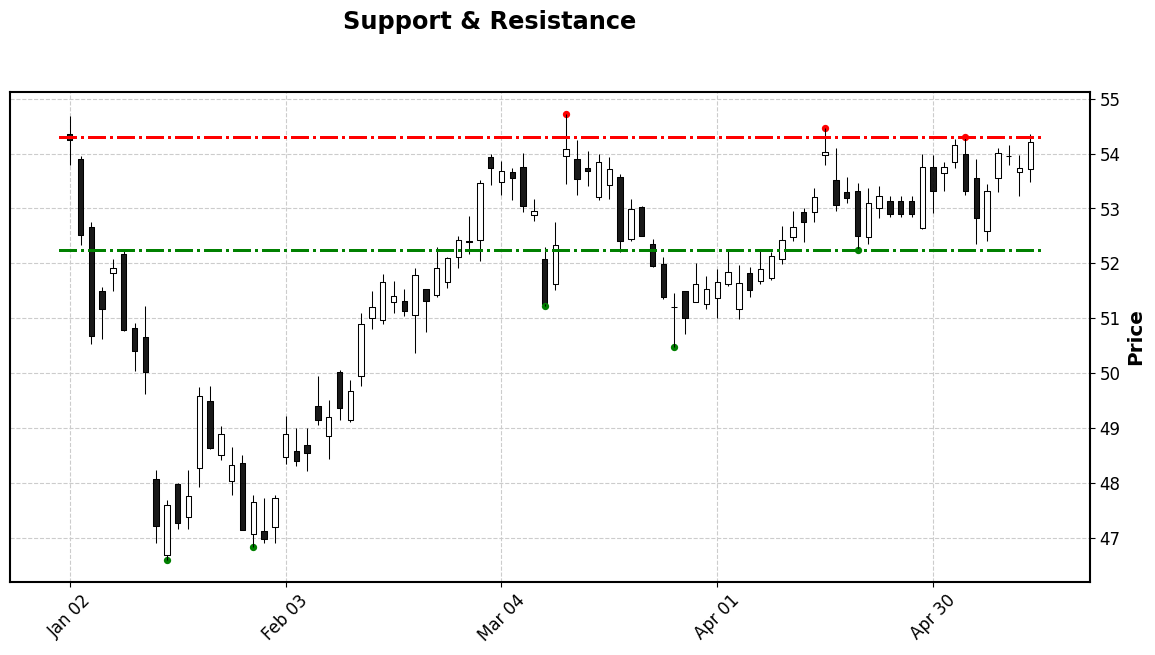

In [6]:
# Get the most recent levels
nearest_support = data_90.loc[data_90.Support.dropna().index.max(), 'Support']
nearest_resistance = data_90.loc[data_90.Resistance.dropna().index.max(), 'Resistance']

# Check for existence of at least one support level
try:
    s = nearest_support
except:
    print("No support found")

# Check for existence of at least one resistance level
try:
    r = nearest_resistance
except:
    print("No resistance found")
    
# Additional plots for marking the support and resistance levels
apd = [mpf.make_addplot(data_90.Support, type='scatter', color="green"),
       mpf.make_addplot(data_90.Resistance, type='scatter', color="red")]

# Plot the OHLC data along with the lines passing through the nearest support and resistance levels
mpf.plot(data_90, type='candle', style='classic',
         addplot=apd, title='Support & Resistance', figsize=(15, 7),hlines=dict(hlines=[s,r],
                     colors=['g','r'],linestyle='-.'))

<a id='functions'></a>
## Functions for Determining the Nearest Support and Resistance Levels

We will create two functions for determining the nearest support and resistance levels. The functions will take `price_data` and `argel_window` as inputs and return the nearest support/resistance levels. These functions will be directly imported from the `price_action_util_quantra` file in the upcoming notebook.

In [7]:
# Function to get the nearest support level
def get_support(price_data, argrel_window = 15):   
    
    # Check whether the length of data is greater than the argel_window
    assert price_data.shape[0] > argrel_window, "Length of data is less then argel_window"        

    # Determine the indices of all support levels
    support_list = argrelextrema(
        price_data['Low'].values, np.less, order=argrel_window)[0]

    
    price_data['support'] = price_data.iloc[support_list, 2]

    # Fetch the last traded price
    ltp = price_data.Close.iloc[-1]
    
    # Get the nearest support level
    price_data['support'] = np.where(price_data['support'] < ltp, price_data['support'], np.nan)

    try:
        return price_data.loc[price_data.support.dropna().index.max(), 'support']    
    except:
        return np.nan

# Function to get the nearest resistance level
def get_resistance(price_data, argrel_window = 15):   

    # Check whether the length of data is greater than the argel_window
    resistance_list = argrelextrema(
        price_data['High'].values, np.greater, order=argrel_window)[0]

    # Determine the indices of all resistance levels
    price_data['resistance'] = price_data.iloc[resistance_list, 1]       

    # Fetch the last traded price
    ltp = price_data.Close.iloc[-1]   
    
    # Get the nearest resistance level
    price_data['resistance'] = np.where(price_data['resistance'] > ltp, price_data['resistance'], np.nan)         

    try:
        return price_data.loc[price_data.resistance.dropna().index.max(), 'resistance']    
    except:
        return np.nan

In [8]:
# We will test the above defined functions by passing 90 days data and argrel window
support = get_support(data_daily.iloc[-180:-90], 15)
resistance = get_resistance(data_daily.iloc[-180:-90], 15)    

# Print LTP
print("Last Traded Price = ", ltp)

# Print the nearest support level
print("Nearest support level = ", support)

# Print the nearest resistance level
print("Nearest resistance level = ", resistance)

Last Traded Price =  54.22
Nearest support level =  41.29
Nearest resistance level =  53.64


<a id='conclusion'></a>
## Conclusion and Next Steps

In this notebook, we saw how we can identify the support and resistance levels. In the upcoming notebook, we will backtest a trading strategy based on support level and check the strategy performance.